# EDA-2: Audit Keputusan Dataset v3 (`ali_f_event_model_ready_v3.csv`)

Notebook ini direvisi agar **tidak misleading** saat ada long-gap (khususnya area 2018-2020).

Fokus:
1. Memastikan visual time-series adil (line putus pada gap panjang)
2. Menilai kualitas data per tahun
3. Menyediakan checklist readiness berbasis threshold
4. Menyediakan tabel kandidat modeling yang eksplisit


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
pd.set_option('display.max_columns', 200)


In [2]:
# Resolve paths from either project root or notebooks/
proc_candidates = [
    Path('../data/processed data/ali_f_event_model_ready_v3.csv'),
    Path('data/processed data/ali_f_event_model_ready_v3.csv'),
]
raw_candidates = [
    Path('../data/raw data/ali_f_raw.csv'),
    Path('data/raw data/ali_f_raw.csv'),
]

for p in proc_candidates:
    if p.exists():
        proc_path = p.resolve()
        break
else:
    raise FileNotFoundError('ali_f_event_model_ready_v3.csv tidak ditemukan')

for p in raw_candidates:
    if p.exists():
        raw_path = p.resolve()
        break
else:
    raw_path = None

print('Processed path:', proc_path)
print('Raw path      :', raw_path)

df = pd.read_csv(proc_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

if raw_path is not None:
    raw = pd.read_csv(raw_path)
    raw['Date'] = pd.to_datetime(raw['Date'])
else:
    raw = None

# Helper columns
threshold_gap = 7
df['year'] = df['Date'].dt.year
df['abs_return'] = df['Return'].abs()
df['is_volume_zero'] = df['Volume'].eq(0)


Processed path: /home/sdo/Project/Machine Learning/INALUM/data/processed data/ali_f_event_model_ready_v3.csv
Raw path      : /home/sdo/Project/Machine Learning/INALUM/data/raw data/ali_f_raw.csv


In [3]:
summary = {
    'rows': len(df),
    'columns': df.shape[1],
    'date_min': df['Date'].min().date(),
    'date_max': df['Date'].max().date(),
    'duplicate_dates': int(df.duplicated('Date').sum()),
    'missing_close': int(df['Close'].isna().sum()),
    'ohlc_invalid_rows': int(((df['High'] < df[['Open','Close','Low']].max(axis=1)) | (df['Low'] > df[['Open','Close','High']].min(axis=1)) | (df['Low'] > df['High'])).sum()),
    'suspect_outlier_true': int(df['is_suspect_outlier'].sum()),
    'long_gap_true': int(df['is_long_gap'].sum()),
    'long_gap_rate_pct': round(df['is_long_gap'].mean()*100, 2),
    'return_nan': int(df['Return'].isna().sum()),
    'volume_zero_pct': round(df['is_volume_zero'].mean()*100, 2),
    'flat_candle_pct': round(df['flat_candle'].mean()*100, 2),
}
pd.DataFrame([summary]).T.rename(columns={0: 'value'})


,value
rows,2336
columns,26
date_min,2014-05-06
date_max,2026-03-04
duplicate_dates,0
missing_close,0
ohlc_invalid_rows,0
suspect_outlier_true,0
long_gap_true,29
long_gap_rate_pct,1.24


## 1) Time Series `Close` (Naive vs Gap-Aware)
Plot kiri = line biasa (bisa misleading).  
Plot kanan = line **diputus** pada `is_long_gap=True` agar transisi lintas gap panjang tidak tampak seolah kontinu.


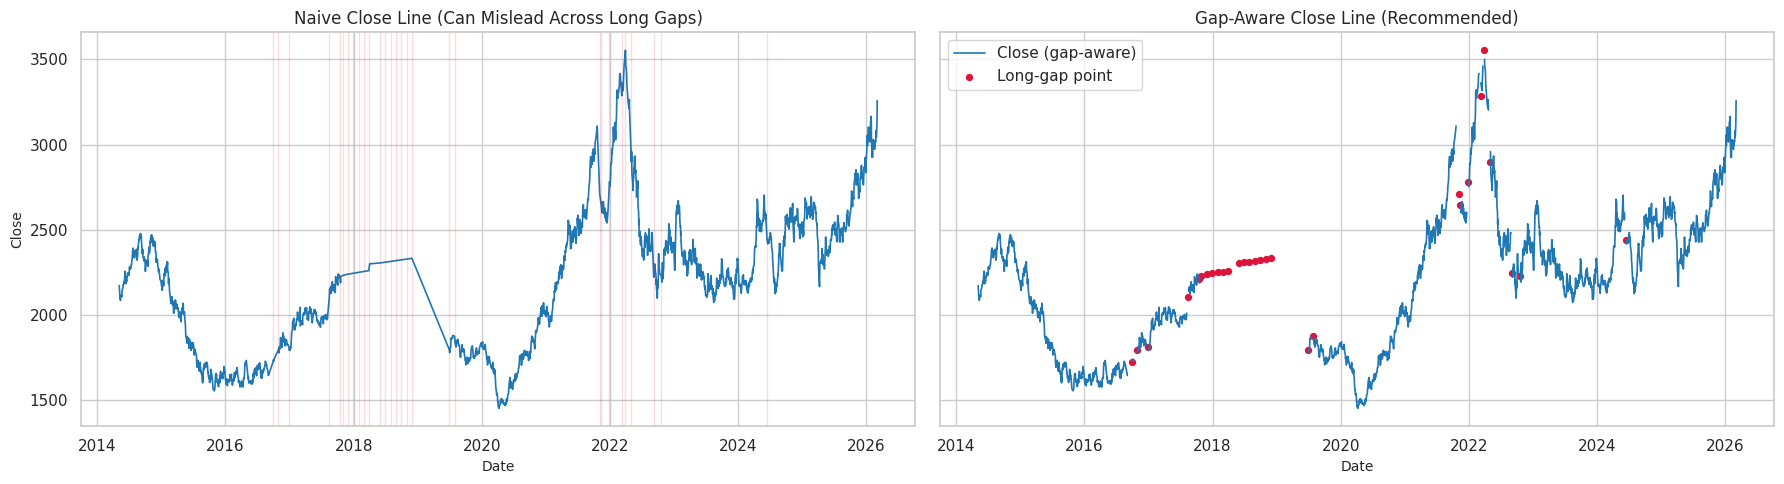

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

# Naive line
axes[0].plot(df['Date'], df['Close'], color='tab:blue', linewidth=1.2)
for d in df.loc[df['is_long_gap'], 'Date']:
    axes[0].axvline(d, color='crimson', alpha=0.15, linewidth=1)
axes[0].set_title('Naive Close Line (Can Mislead Across Long Gaps)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Close')

# Gap-aware line: break line at long-gap rows
close_gap_aware = df['Close'].where(~df['is_long_gap'], np.nan)
axes[1].plot(df['Date'], close_gap_aware, color='tab:blue', linewidth=1.2, label='Close (gap-aware)')
axes[1].scatter(df.loc[df['is_long_gap'], 'Date'], df.loc[df['is_long_gap'], 'Close'], color='crimson', s=18, label='Long-gap point')
axes[1].set_title('Gap-Aware Close Line (Recommended)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


## 2) Zoom Area Kritis 2017-2020 (Gap-Aware)


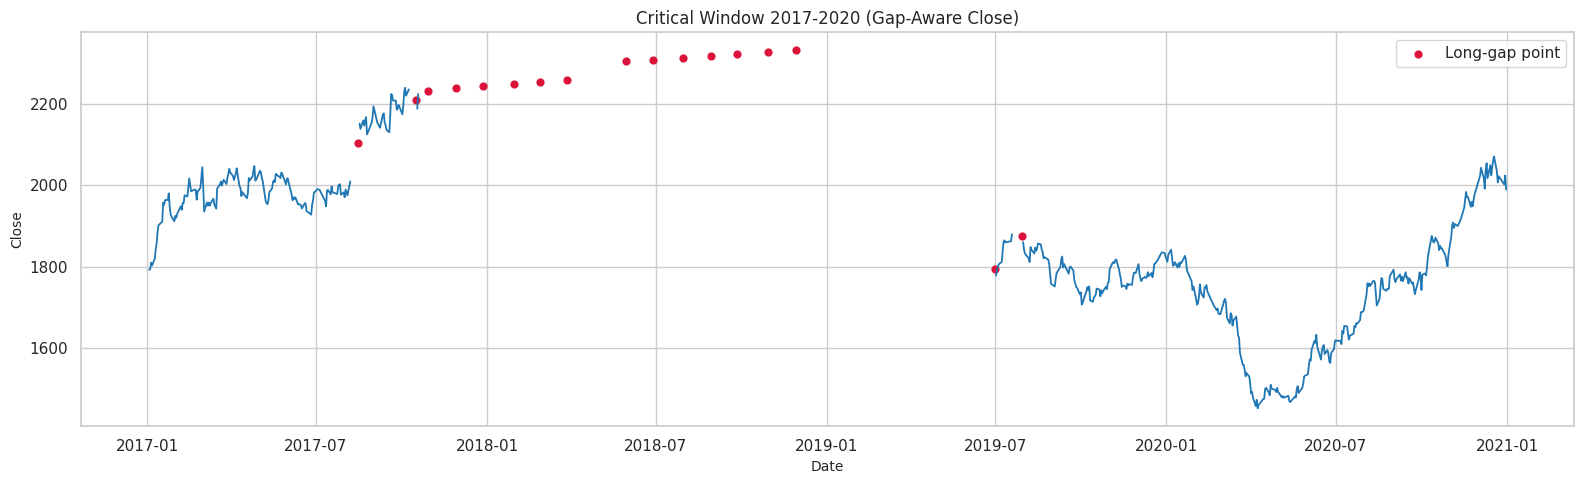

,Date,Close,gap_days,is_long_gap,Return,Volume
799,2019-07-01,1793.50,214.0,True,NaN,0
792,2018-05-30,2305.00,58.0,True,NaN,0
797,2018-10-30,2328.25,33.0,True,NaN,0
788,2018-01-30,2250.00,33.0,True,NaN,0
794,2018-07-30,2313.50,32.0,True,NaN,0
795,2018-08-30,2318.75,31.0,True,NaN,0
786,2017-11-29,2239.50,30.0,True,NaN,0
798,2018-11-29,2332.50,30.0,True,NaN,0
787,2017-12-28,2244.50,29.0,True,NaN,0
793,2018-06-28,2309.25,29.0,True,NaN,0


In [5]:
zoom = df[(df['Date'] >= '2017-01-01') & (df['Date'] <= '2020-12-31')].copy()
zoom_line = zoom['Close'].where(~zoom['is_long_gap'], np.nan)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(zoom['Date'], zoom_line, color='tab:blue', linewidth=1.3)
ax.scatter(zoom.loc[zoom['is_long_gap'], 'Date'], zoom.loc[zoom['is_long_gap'], 'Close'], color='crimson', s=24, label='Long-gap point')
ax.set_title('Critical Window 2017-2020 (Gap-Aware Close)')
ax.set_xlabel('Date')
ax.set_ylabel('Close')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

zoom[['Date', 'Close', 'gap_days', 'is_long_gap', 'Return', 'Volume']].sort_values('gap_days', ascending=False).head(20)


## 3) Return dan Volatilitas: Event-Based vs Time-Aware
- `Rolling 30-event std`: sensitif terhadap jumlah event, bukan jarak waktu kalender.
- `Rolling 90D std`: lebih fair untuk interpretasi time-series saat ada long-gap.


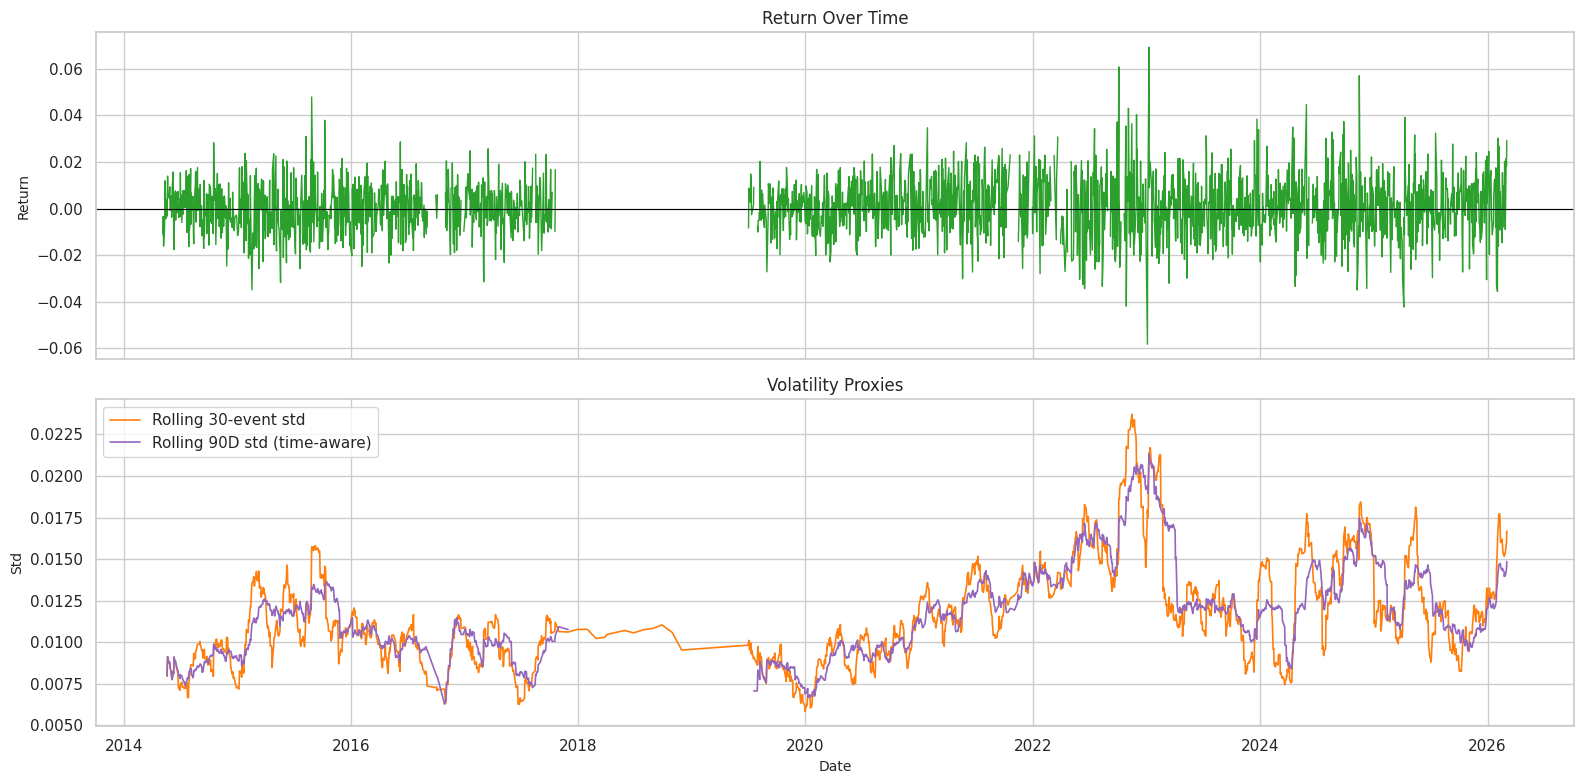

In [6]:
ret = df.set_index('Date')['Return']
roll_event = ret.rolling(30, min_periods=10).std()
roll_time = ret.rolling('90D', min_periods=10).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df['Date'], df['Return'], color='tab:green', linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Return Over Time')
axes[0].set_ylabel('Return')

axes[1].plot(roll_event.index, roll_event.values, color='tab:orange', linewidth=1.2, label='Rolling 30-event std')
axes[1].plot(roll_time.index, roll_time.values, color='tab:purple', linewidth=1.2, label='Rolling 90D std (time-aware)')
axes[1].set_title('Volatility Proxies')
axes[1].set_ylabel('Std')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


## 4) Gap Diagnostics


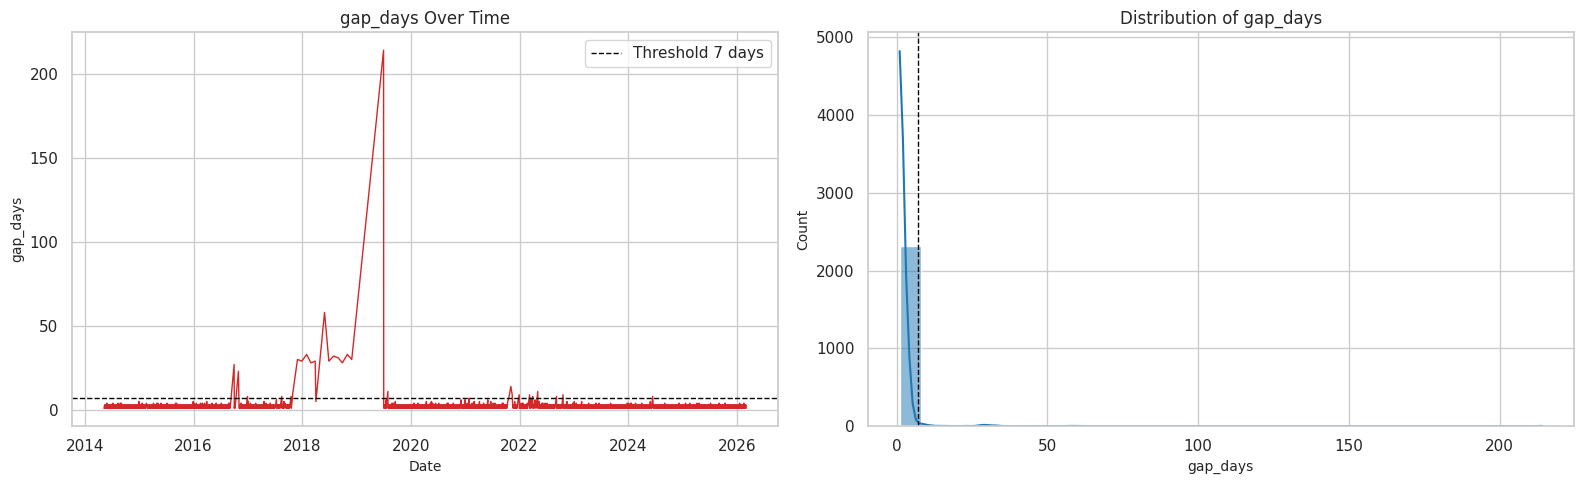

,Date,Close,gap_days,Return,Volume
799,2019-07-01,1793.50,214.0,NaN,0
792,2018-05-30,2305.00,58.0,NaN,0
788,2018-01-30,2250.00,33.0,NaN,0
797,2018-10-30,2328.25,33.0,NaN,0
794,2018-07-30,2313.50,32.0,NaN,0
795,2018-08-30,2318.75,31.0,NaN,0
786,2017-11-29,2239.50,30.0,NaN,0
798,2018-11-29,2332.50,30.0,NaN,0
787,2017-12-28,2244.50,29.0,NaN,0
790,2018-03-28,2260.00,29.0,NaN,0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df['Date'], df['gap_days'], color='tab:red', linewidth=1)
axes[0].axhline(threshold_gap, color='black', linestyle='--', linewidth=1, label=f'Threshold {threshold_gap} days')
axes[0].set_title('gap_days Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('gap_days')
axes[0].legend(loc='upper right')

sns.histplot(df['gap_days'].dropna(), bins=30, kde=True, ax=axes[1], color='tab:blue')
axes[1].axvline(threshold_gap, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of gap_days')
axes[1].set_xlabel('gap_days')

plt.tight_layout()
plt.show()

long_gap_tbl = df.loc[df['is_long_gap'], ['Date', 'Close', 'gap_days', 'Return', 'Volume']].sort_values('gap_days', ascending=False)
long_gap_tbl.head(20)


## 5) Distribusi Return (dengan konteks long-gap)


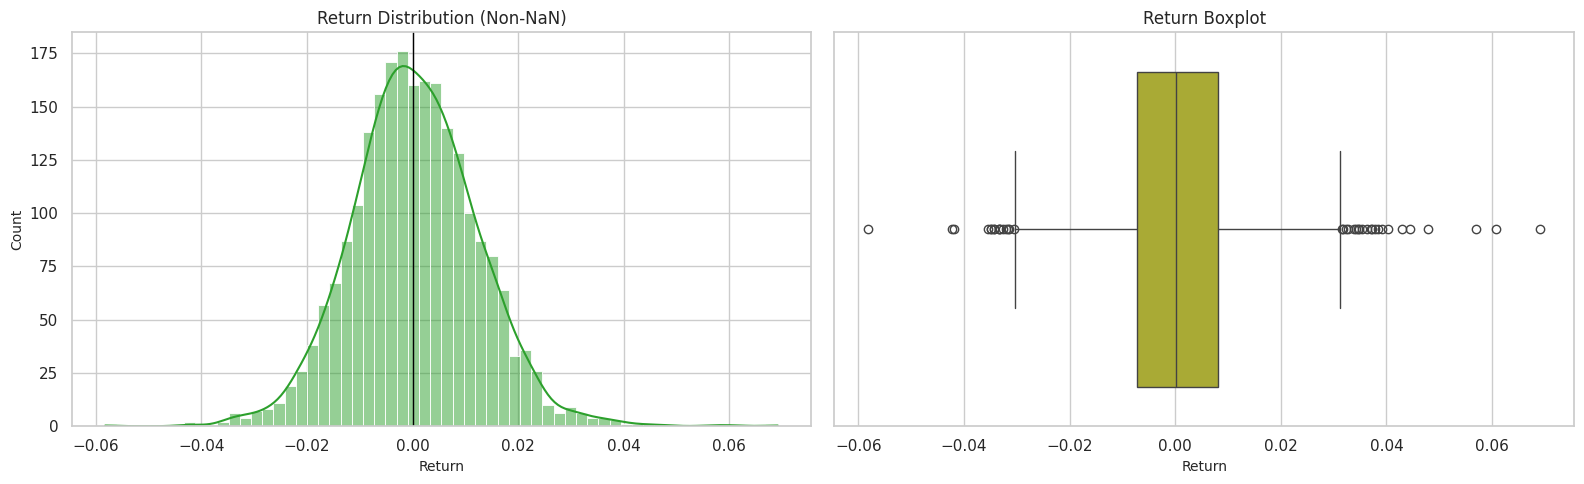

count    2306.000000
mean        0.000468
std         0.012008
min        -0.058189
1%         -0.027368
5%         -0.018395
50%         0.000142
95%         0.020158
99%         0.031115
max         0.069139
Name: Return, dtype: float64

In [8]:
ret_non_nan = df['Return'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(ret_non_nan, bins=60, kde=True, ax=axes[0], color='tab:green')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Return Distribution (Non-NaN)')

sns.boxplot(x=ret_non_nan, ax=axes[1], color='tab:olive')
axes[1].set_title('Return Boxplot')
axes[1].set_xlabel('Return')

plt.tight_layout()
plt.show()

ret_non_nan.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


## 6) Coverage Audit per Tahun (Raw vs v3)
Bagian ini penting untuk menguji apakah ada tahun yang terlalu sedikit event-nya setelah cleaning.


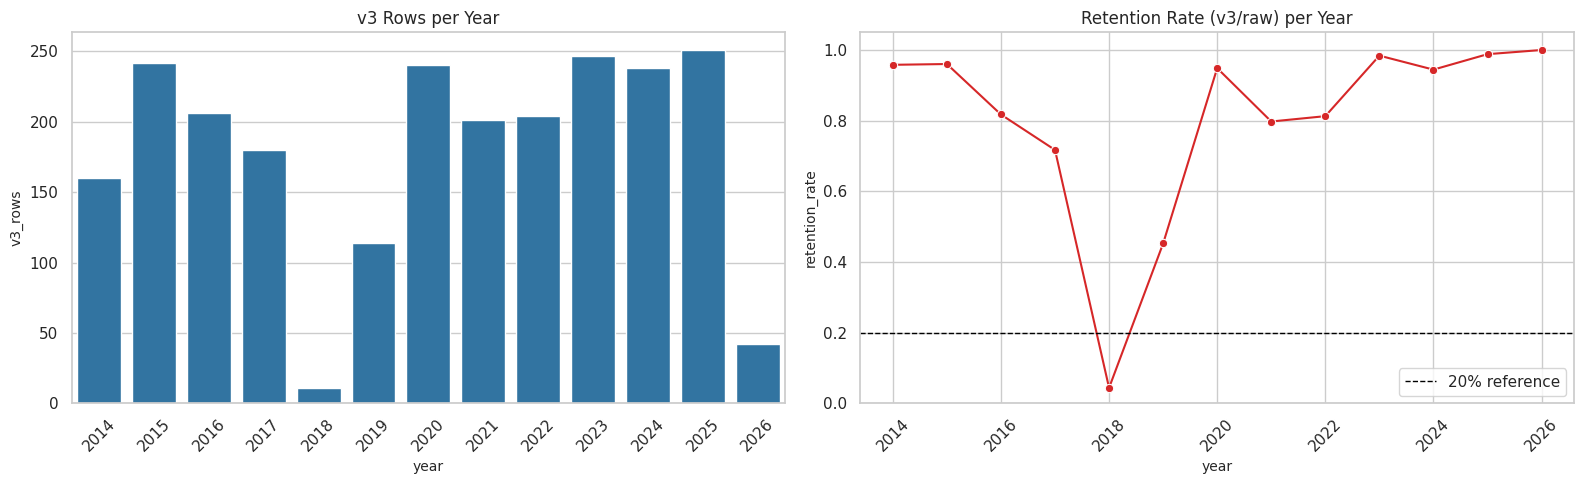

In [9]:
if raw is not None:
    raw_year = raw.groupby(raw['Date'].dt.year).size().rename('raw_rows')
    v3_year = df.groupby('year').size().rename('v3_rows')
    coverage = pd.concat([raw_year, v3_year], axis=1).fillna(0)
    coverage['retention_rate'] = coverage['v3_rows'] / coverage['raw_rows']
    coverage = coverage.reset_index().rename(columns={'index': 'year', 'Date': 'year'})

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(data=coverage, x='year', y='v3_rows', color='tab:blue', ax=axes[0])
    axes[0].set_title('v3 Rows per Year')
    axes[0].tick_params(axis='x', rotation=45)

    sns.lineplot(data=coverage, x='year', y='retention_rate', marker='o', color='tab:red', ax=axes[1])
    axes[1].axhline(0.2, color='black', linestyle='--', linewidth=1, label='20% reference')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('Retention Rate (v3/raw) per Year')
    axes[1].legend(loc='lower right')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    coverage
else:
    print('Raw data tidak tersedia; coverage raw vs v3 dilewati.')


## 7) Kualitas Tahunan Inti


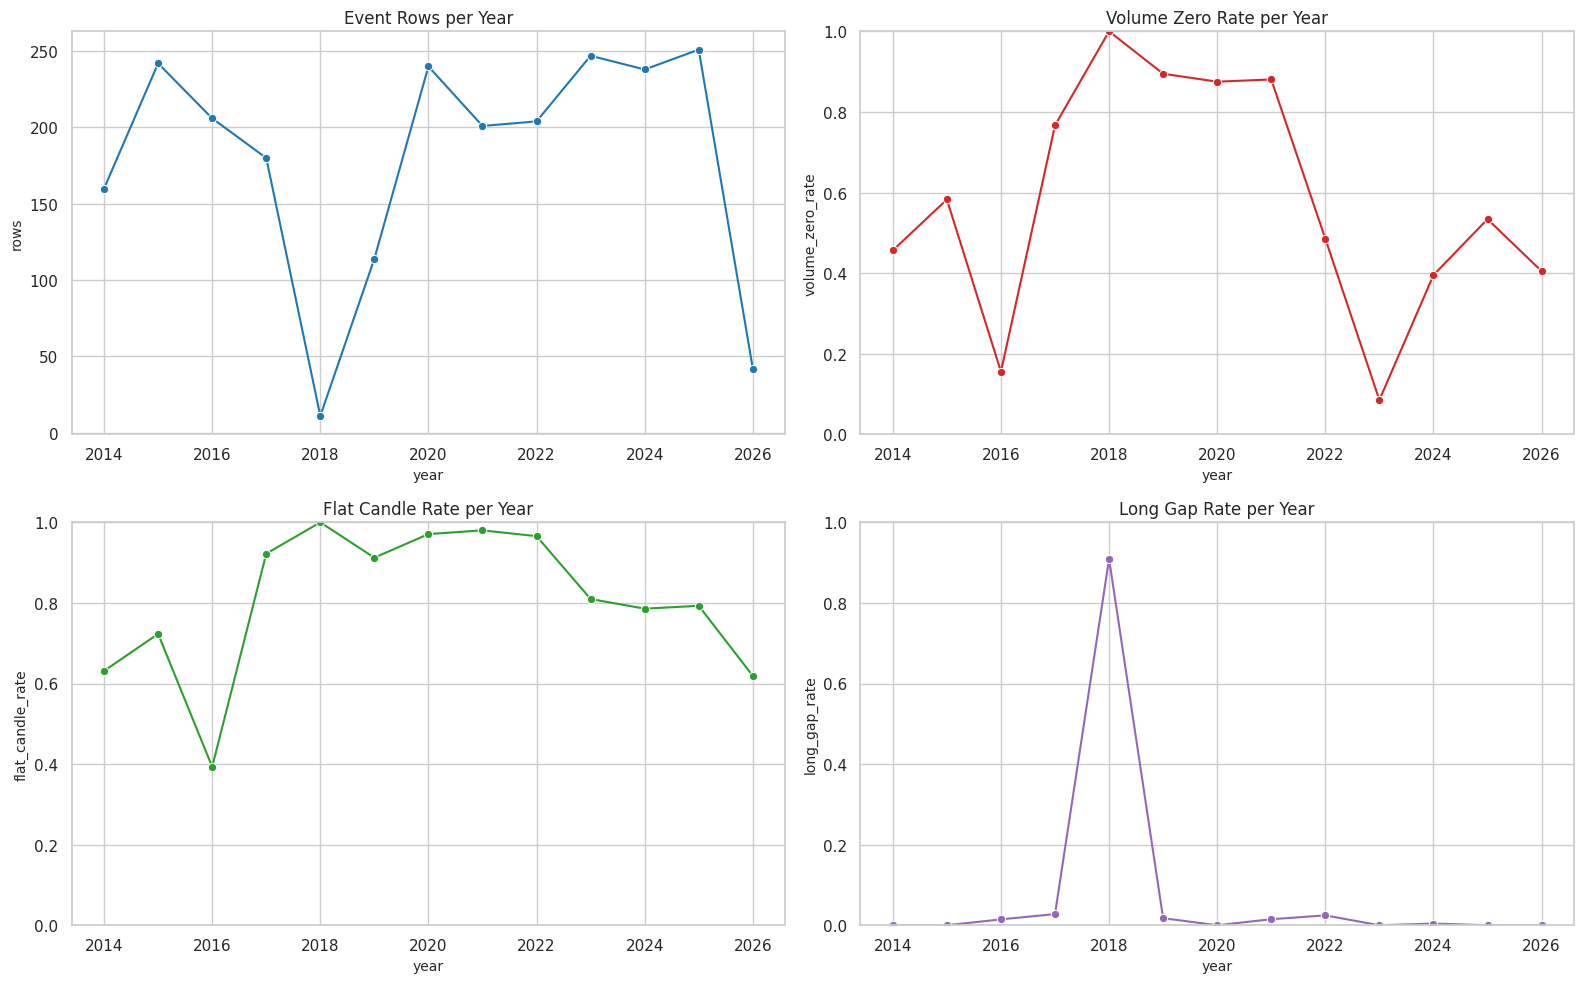

,year,rows,volume_zero_rate,flat_candle_rate,long_gap_rate,mean_abs_return,return_na_rate
0,2014,160,0.456250,0.631250,0.000000,0.007128,0.006250
1,2015,242,0.582645,0.723140,0.000000,0.009402,0.000000
2,2016,206,0.155340,0.393204,0.014563,0.008017,0.014563
3,2017,180,0.766667,0.922222,0.027778,0.007327,0.027778
4,2018,11,1.000000,1.000000,0.909091,0.017699,0.909091
5,2019,114,0.894737,0.912281,0.017544,0.006197,0.017544
6,2020,240,0.875000,0.970833,0.000000,0.008153,0.000000
7,2021,201,0.880597,0.980100,0.014925,0.010335,0.014925
8,2022,204,0.485294,0.965686,0.024510,0.013375,0.024510
9,2023,247,0.085020,0.809717,0.000000,0.010163,0.000000


In [10]:
yearly = df.groupby('year').agg(
    rows=('Date', 'size'),
    volume_zero_rate=('is_volume_zero', 'mean'),
    flat_candle_rate=('flat_candle', 'mean'),
    long_gap_rate=('is_long_gap', 'mean'),
    mean_abs_return=('abs_return', 'mean'),
    return_na_rate=('Return', lambda s: s.isna().mean()),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.lineplot(data=yearly, x='year', y='rows', marker='o', ax=axes[0, 0], color='tab:blue')
axes[0, 0].set_title('Event Rows per Year')

sns.lineplot(data=yearly, x='year', y='volume_zero_rate', marker='o', ax=axes[0, 1], color='tab:red')
axes[0, 1].set_title('Volume Zero Rate per Year')
axes[0, 1].set_ylim(0, 1)

sns.lineplot(data=yearly, x='year', y='flat_candle_rate', marker='o', ax=axes[1, 0], color='tab:green')
axes[1, 0].set_title('Flat Candle Rate per Year')
axes[1, 0].set_ylim(0, 1)

sns.lineplot(data=yearly, x='year', y='long_gap_rate', marker='o', ax=axes[1, 1], color='tab:purple')
axes[1, 1].set_title('Long Gap Rate per Year')
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

yearly


## 8) Correlation (Tanpa Kolom Redundan)
`Adj Close` dikeluarkan karena identik dengan `Close`.


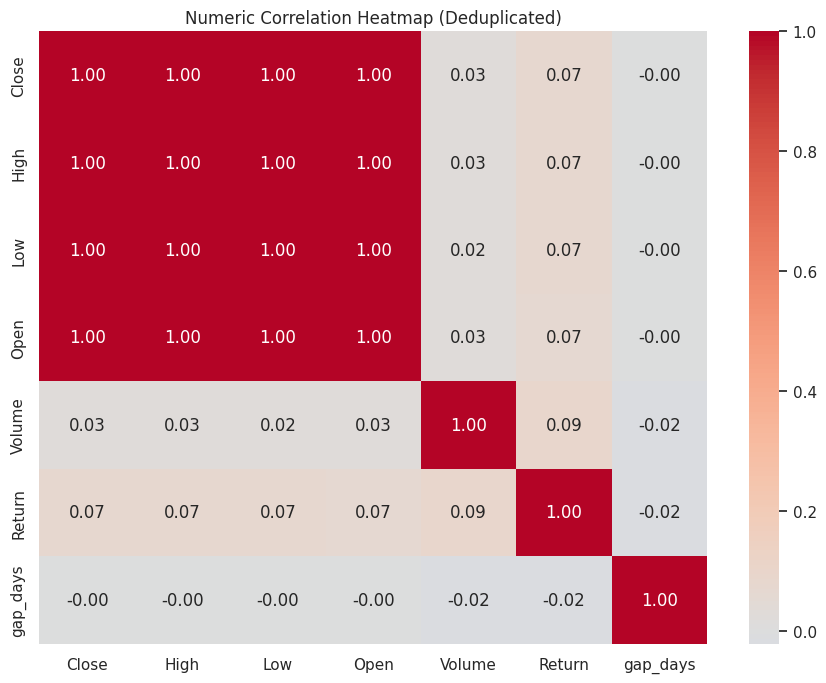

In [11]:
num_cols = ['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'gap_days']
corr = df[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric Correlation Heatmap (Deduplicated)')
plt.tight_layout()
plt.show()


## 9) Readiness Checklist (Threshold-Based)
Aturan ini sengaja dibuat lebih ketat agar keputusan tidak bias "terlihat bagus".


In [12]:
long_gap_rate = float(df['is_long_gap'].mean())
volume_zero_rate = float(df['is_volume_zero'].mean())
flat_candle_rate = float(df['flat_candle'].mean())

if raw is not None:
    raw_year = raw.groupby(raw['Date'].dt.year).size().rename('raw_rows')
    v3_year = df.groupby('year').size().rename('v3_rows')
    cov = pd.concat([raw_year, v3_year], axis=1).fillna(0)
    cov['retention_rate'] = cov['v3_rows'] / cov['raw_rows']
    min_retention = float(cov['retention_rate'].min())
else:
    min_retention = np.nan

checks = [
    ('No missing OHLC', int(df[['Open','High','Low','Close']].isna().any(axis=1).sum()) == 0, 'must pass'),
    ('No OHLC invalid', int(((df['High'] < df[['Open','Close','Low']].max(axis=1)) | (df['Low'] > df[['Open','Close','High']].min(axis=1)) | (df['Low'] > df['High'])).sum()) == 0, 'must pass'),
    ('No suspect outlier', int(df['is_suspect_outlier'].sum()) == 0, 'must pass'),
    ('Long-gap rate <= 5%', long_gap_rate <= 0.05, f'current={long_gap_rate:.2%}'),
    ('Volume-zero rate <= 60%', volume_zero_rate <= 0.60, f'current={volume_zero_rate:.2%}'),
    ('Flat-candle rate <= 85%', flat_candle_rate <= 0.85, f'current={flat_candle_rate:.2%}'),
    ('Min yearly retention >= 20%', (not np.isnan(min_retention)) and (min_retention >= 0.20), f'current={min_retention:.2%}' if not np.isnan(min_retention) else 'raw N/A'),
]

check_df = pd.DataFrame(checks, columns=['check', 'pass', 'note'])
check_df['status'] = np.where(check_df['pass'], 'PASS', 'REVIEW')
check_df


,check,pass,note,status
0,No missing OHLC,True,must pass,PASS
1,No OHLC invalid,True,must pass,PASS
2,No suspect outlier,True,must pass,PASS
3,Long-gap rate <= 5%,True,current=1.24%,PASS
4,Volume-zero rate <= 60%,True,current=53.47%,PASS
5,Flat-candle rate <= 85%,True,current=80.35%,PASS
6,Min yearly retention >= 20%,False,current=4.38%,REVIEW


## 10) Candidate Modeling Table (Lebih Eksplisit)
Contoh target: `target_next_return = Return.shift(-1)`.

Di bawah ini ditampilkan dua skenario:
1. `baseline_rows`: hanya drop target NaN
2. `strict_rows_no_long_gap`: drop baris long-gap agar training lebih stabil


In [13]:
mdl = df.copy()
mdl['target_next_return'] = mdl['Return'].shift(-1)

baseline = mdl.dropna(subset=['target_next_return']).copy()
strict = baseline[~baseline['is_long_gap']].copy()

print('baseline_rows            :', len(baseline))
print('strict_rows_no_long_gap  :', len(strict))

split_point = int(len(strict) * 0.8)
train = strict.iloc[:split_point]
test = strict.iloc[split_point:]

print('train_rows:', len(train), '| test_rows:', len(test))
print('train_range:', train['Date'].min().date(), '->', train['Date'].max().date())
print('test_range :', test['Date'].min().date(), '->', test['Date'].max().date())

strict[['Date', 'Close', 'Return', 'gap_days', 'is_long_gap', 'target_next_return']].head(12)


baseline_rows            : 2306
strict_rows_no_long_gap  : 2290
train_rows: 1832 | test_rows: 458
train_range: 2014-05-06 -> 2024-04-12
test_range : 2024-04-15 -> 2026-03-03


,Date,Close,Return,gap_days,is_long_gap,target_next_return
0,2014-05-06,2172.75,NaN,NaN,False,-0.010931
1,2014-05-07,2149.00,-0.010931,1.0,False,-0.003374
2,2014-05-08,2141.75,-0.003374,1.0,False,-0.016108
3,2014-05-09,2107.25,-0.016108,1.0,False,-0.009016
4,2014-05-12,2088.25,-0.009016,3.0,False,-0.001437
5,2014-05-13,2085.25,-0.001437,1.0,False,0.011869
6,2014-05-14,2110.00,0.011869,1.0,False,0.002607
7,2014-05-15,2115.50,0.002607,1.0,False,-0.004372
8,2014-05-16,2106.25,-0.004372,1.0,False,0.003561
9,2014-05-19,2113.75,0.003561,3.0,False,-0.003312


## Kesimpulan yang Harus Dibaca dari Notebook Ini
- Area 2018-2020 memang perlu perhatian tinggi karena coverage event sangat tipis (terutama 2018).
- Visual gap-aware harus dijadikan acuan utama, bukan line naive.
- Dataset v3 bisa dipakai, tetapi keputusan final sebaiknya membandingkan:
  1. training full data v3
  2. training tanpa long-gap rows (atau mulai dari periode lebih stabil)
